# Inference on test set

Uses fitted parameters (from `fit-model.ipynb`) and the **collapsed Gibbs**
sampler (`infer_all_collapsed`) to infer $z$ and $C$ for every test home
from **total load alone**.

**C update**: each Gibbs iteration, $C$ is sampled from its exact marginal
posterior
$$p(C \mid x, \Theta, \eta, \omega) \;\propto\; p(C)\, p(x \mid C, \Theta, \eta, \omega),$$
with the $C{=}1$ likelihood coming from the HMM forward-pass marginal
(marginalising over $z$) and the $C{=}0$ likelihood from the closed-form
all-off Gaussian. $z$ is then drawn from the backward conditional when $C=1$,
or pinned to all-off when $C=0$.


In [1]:
import sys
from pathlib import Path
repo_root = str(Path('.').resolve().parents[1])
utils_dir = str(Path('.').resolve().parents[1] / 'notebooks' / 'utils')
for p in [repo_root, utils_dir]:
    if p not in sys.path: sys.path.insert(0, p)

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models import graphical_model as gm
from models import first_diff_logistic as fdl
import convergence_plots as cvg
import background_plots as bgp


## 1. Load fitted parameters

In [2]:
rank = 20
params = pickle.load(open(f'../../models/fitted_params-milestone4-rank{rank}-global_omega.pkl', 'rb'))
print(params.summary())


ModelParams summary
----------------------------------------
EV States
  p_C                 = 0.1667
  pi_z                = [0.8304 0.0419 0.1276]
  P_z (rows sum to 1):
      off: [0.9875 0.0085 0.004 ]
      low: [0.3498 0.515  0.1352]
     high: [0.0232 0.1294 0.8474]

EV Charging Magnitudes
  Theta[ off]: mu=+0.0000, sigma_Theta=0.0000, sigma^EV=0.0010
  Theta[ low]: mu=+0.8727, sigma_Theta=0.1326, sigma^EV=0.4859
  Theta[high]: mu=+3.5616, sigma_Theta=0.6219, sigma^EV=0.7378

Non-EV — hierarchical eta prior
  eta_bar             (min=+0.617, median=+0.947, max=+1.326, mean=+0.957)
  W_eta               shape=(T=96, r=20)
  psi_eta             (per-t residual variance: min=0.0000, median=0.0000, max=0.0000)

Non-EV — omega parameterization: 'global'
  sigma2_nev_global   (fixed at inference; per-t std-dev: min=0.554, median=0.916, max=1.231)


In [3]:
# Compare rank-1 vs rank-20 PPCA prior covariance Sigma_eta = W W^T + diag(psi).
# Loads both fits explicitly so the comparison is between two separate runs of
# `fit(..., ppca_rank=r)`, not a truncation of the same fit. Relative Frobenius
# norm is the conventional measure for PSD matrix discrepancy.
from pathlib import Path
_root = Path('../../models')
_pkl  = lambda r: _root / f'fitted_params-milestone4-rank{r}-global_omega.pkl'

params_r1  = pickle.load(open(_pkl(1),  'rb'))
params_r20 = pickle.load(open(_pkl(20), 'rb'))

Sigma_r1  = params_r1.W_eta  @ params_r1.W_eta.T  + np.diag(params_r1.psi_eta)
Sigma_r20 = params_r20.W_eta @ params_r20.W_eta.T + np.diag(params_r20.psi_eta)

diff_F   = np.linalg.norm(Sigma_r20 - Sigma_r1, 'fro')
S_r1_F   = np.linalg.norm(Sigma_r1,  'fro')
S_r20_F  = np.linalg.norm(Sigma_r20, 'fro')

rel_to_r1   = diff_F / S_r1_F                       # how much r=20 adds, relative to r=1
rel_to_avg  = diff_F / (0.5 * (S_r1_F + S_r20_F))   # symmetric variant
rel_to_r20  = diff_F / S_r20_F

print(f'||Sigma_eta(r=20) - Sigma_eta(r=1)||_F             = {diff_F:.4f}')
print(f'||Sigma_eta(r=1)||_F                                = {S_r1_F:.4f}')
print(f'||Sigma_eta(r=20)||_F                               = {S_r20_F:.4f}')
print(f'relative Frobenius (vs r=1)                        = {rel_to_r1:.4f}')
print(f'relative Frobenius (symmetric, vs avg)             = {rel_to_avg:.4f}')
print(f'relative Frobenius (vs r=20)                       = {rel_to_r20:.4f}')

# Spectral-norm comparison (largest singular value of the difference) — useful
# when the rank-20 fit's extra modes carry small but non-Frobenius-dominant energy.
spec_diff = np.linalg.norm(Sigma_r20 - Sigma_r1, 2)
spec_r1   = np.linalg.norm(Sigma_r1, 2)
print(f'relative spectral norm (vs r=1)                    = {spec_diff/spec_r1:.4f}')

||Sigma_eta(r=20) - Sigma_eta(r=1)||_F             = 10.3614
||Sigma_eta(r=1)||_F                                = 36.6580
||Sigma_eta(r=20)||_F                               = 37.9456
relative Frobenius (vs r=1)                        = 0.2827
relative Frobenius (symmetric, vs avg)             = 0.2778
relative Frobenius (vs r=20)                       = 0.2731
relative spectral norm (vs r=1)                    = 0.2774


## 2. Train set + heuristic baseline

Fit the logistic model on train homes (to use for warm-starting and baseline comparison).

In [4]:
def load_split(pkl_path: str) -> pd.DataFrame:
    raw = pickle.load(open(pkl_path, 'rb'))
    df = pd.concat(
        [d.assign(home_id=h, has_ev=ev, city=c)
         for h, (ev, c, d) in raw.items()]
    ).reset_index()
    df.rename(columns={'car1': 'ev_load', 'load': 'total_load'}, inplace=True)
    df['day']        = df['localminute'].dt.normalize()
    df['time']       = df['localminute'].dt.strftime('%H:%M')
    df               = df.drop(columns='localminute')
    df['time']       = pd.to_timedelta(df['time'] + ':00')
    df['time_index'] = (df['time'].dt.total_seconds() // (15 * 60)).astype(int)
    df['charge_state'] = df['charge_state'].astype('int')
    mask = (df.groupby(['home_id', 'day'])['time_index']
              .transform(lambda x: x.nunique() == 96))
    return df[mask]

train_df = load_split('../../data_processing/splits/train.pkl')
print(f'Train: {train_df.home_id.nunique()} homes, '
      f'{train_df["has_ev"].map(int).groupby(train_df["home_id"]).first().sum()} EV')


Train: 54 homes, 9 EV


In [5]:
homes_train = gm.build_heuristic_homes(train_df)
logistic_model, w, lo, hi, md = fdl.tune(homes_train)
print(f'Heuristic tuned: window={w*15}min  low={lo:.2f}  high={hi:.2f}  max_dur={md}')


Best: window=6 (90 min), low=1.2, high=1.6, max_duration=16 (240 min)  (train avg precision=0.5502)
Heuristic tuned: window=90min  low=1.20  high=1.60  max_dur=16


## 3. Load test set and run heuristic warm-start

The heuristic is used **only** to warm-start C and z (shortening burn-in).
Inference itself sees only `total_load`.

In [6]:
test_df = load_split('../../data_processing/splits/test.pkl')
print(f'Test: {test_df.home_id.nunique()} homes, '
      f'{test_df["has_ev"].map(int).groupby(test_df["home_id"]).first().sum()} EV')
test_df.groupby('home_id')['has_ev'].first().value_counts().rename('count').to_frame()


Test: 18 homes, 3 EV


,count
has_ev,
False,15
True,3


In [7]:
# Run heuristic on test homes to get warm-start C and z values
homes_test = gm.build_heuristic_homes(test_df)
heuristic_summary_test, heuristic_states_test = fdl.predict(
    logistic_model, homes_test, w, lo, hi, md
)
heuristic_summary_test['C_hat'] = (heuristic_summary_test['p_hat'] >= 0.5).astype(int)

heuristic_c_probs = dict(zip(
    heuristic_summary_test['dataid'].astype(int),
    heuristic_summary_test['p_hat'].astype(float),
))
heuristic_c_hat = dict(zip(
    heuristic_summary_test['dataid'].astype(int),
    heuristic_summary_test['C_hat'].astype(int),
))

# Build initial z from heuristic state estimates (1-D flat → (D,T))
init_z_dict = {}
for hid, z_flat in heuristic_states_test.items():
    g = test_df[test_df['home_id'] == hid]
    D = g['day'].nunique()
    init_z_dict[int(hid)] = z_flat[:D * 96].reshape(D, 96)

print('Heuristic predictions on test homes:')
print(heuristic_summary_test.to_string(index=False))


Heuristic predictions on test homes:
 dataid  has_ev  transitions_per_day  p_hat  C_hat
    142       0                0.000  0.152      0
   1222       1                3.295  0.933      1
   1417       0                0.590  0.281      0
   1642       1                2.264  0.782      1
   2318       0                0.219  0.193      0
   3517       0                0.033  0.158      0
   4495       0                0.000  0.152      0
   5587       0                0.514  0.261      0
   5679       1                1.978  0.710      1
   5746       0                0.000  0.152      0
   7114       0                0.389  0.230      0
   7800       0                1.151  0.451      0
   8061       0                0.393  0.232      0
   8386       0                0.064  0.163      0
   8565       0                0.689  0.308      0
   9019       0                0.042  0.159      0
   9160       0                0.081  0.166      0
   9775       0                0.000  0.152  

## 4. Gibbs inference on all test homes

In [17]:
# ── CONFIGURE ──────────────────────────────────────────────────────────────
S_BURN   = 200
S_RETAIN = 700
SEED     = 0
# HOME_IDS = [1222, 1417]
HOME_IDS = test_df.home_id.unique()
# ───────────────────────────────────────────────────────────────────────────


In [18]:
_ids         = set(HOME_IDS)
test_df_sub  = test_df[test_df['home_id'].isin(_ids)]

# Collapsed Gibbs: samples C from its exact marginal posterior at each
# iteration (marginalising over z via the HMM forward pass), then z|C.
# No warm-start: collapsed sampler cold-starts from z=off, theta=mu_theta,
# eta=eta_bar. The heuristic predictions remain available above for
# comparison/diagnostics but are not fed into Gibbs.
inferences = gm.infer_all_collapsed(
    test_df_sub, params,
    S_burn=S_BURN, S=S_RETAIN, seed=SEED,
    verbose=True,
)

INFERENCE: collapsed Gibbs over all homes

[1/18] home 142  D=183  true_c=0
  [home 142] D=183 → collapsed Gibbs (200 burn-in + 700 retained)
    iter    1/900 [burn-in]  C=0  Θ_low=0.855  Θ_high=3.960  η∈[+0.37,+0.74]  logL=-14794.8  (0.0s)
    iter    2/900 [burn-in]  C=0  Θ_low=0.939  Θ_high=4.177  η∈[+0.39,+0.76]  logL=-14796.3  (0.1s)
    iter    3/900 [burn-in]  C=0  Θ_low=0.950  Θ_high=3.149  η∈[+0.37,+0.77]  logL=-14798.6  (0.1s)
    iter  100/900 [burn-in]  C=0  Θ_low=0.948  Θ_high=2.827  η∈[+0.35,+0.76]  logL=-14797.8  (1.9s)
    iter  200/900 [burn-in]  C=0  Θ_low=0.631  Θ_high=3.437  η∈[+0.39,+0.79]  logL=-14797.7  (3.5s)
    iter  201/900 [keep  ]  C=0  Θ_low=0.518  Θ_high=2.327  η∈[+0.40,+0.76]  logL=-14791.7  (3.5s)
    iter  300/900 [keep  ]  C=0  Θ_low=0.722  Θ_high=3.135  η∈[+0.38,+0.77]  logL=-14793.1  (5.4s)
    iter  400/900 [keep  ]  C=0  Θ_low=0.734  Θ_high=3.571  η∈[+0.40,+0.73]  logL=-14796.6  (7.2s)
    iter  500/900 [keep  ]  C=0  Θ_low=0.917  Θ_high=2.398  η

## 5. z confusion matrices

Per-home row-normalised confusion, then averaged over homes. Separate for EV and non-EV. Hard (MAP) and soft (posterior) versions for Gibbs; hard only for heuristic baseline.

In [19]:
# Build C-probability dicts
c_probs_gibbs    = {hid: float(inf.c_samples.mean())    for hid, inf in inferences.items()}
c_probs_baseline = dict(heuristic_c_probs)

# MAP-z → heuristic: count transitions/day in the Gibbs MAP z, then apply the
# tuned logistic model (same one used for the heuristic baseline).
c_probs_map_z_heur = {}
for hid, inf in inferences.items():
    z_flat = inf.z_hat.ravel()                           # MAP z, shape (D*96,)
    rate   = float((np.diff(z_flat) != 0).sum()) / (len(z_flat) / 96)
    c_probs_map_z_heur[hid] = float(logistic_model.predict_proba([[rate]])[0, 1])

c_prob_methods = {
    'gibbs':           c_probs_gibbs,
    'baseline':        c_probs_baseline,
    'map_z+heuristic': c_probs_map_z_heur,
}

results = gm.evaluate(
    test_df_sub, inferences,
    c_prob_methods   = c_prob_methods,
    heuristic_states = heuristic_states_test,
)

# Print z confusion tables only
from models.graphical_model import STATE_NAMES
SEP = '─' * 64

def fmt_row(label, row):
    cells = '  '.join(f'{"NaN":>7}' if np.isnan(v) else f'{v:>7.3f}' for v in row)
    return f'  {label:<8} {cells}'

for group, home_ids, hard_cm, soft_cm, heur_cm in [
    ('EV (C_true=1)',     results['ev_home_ids'],     results['ev_z_hard'],     results['ev_z_soft'],     results['ev_z_heur']),
    ('non-EV (C_true=0)', results['non_ev_home_ids'], results['non_ev_z_hard'], results['non_ev_z_soft'], results['non_ev_z_heur']),
]:
    n = len(home_ids)
    print(f'\n{SEP}')
    print(f'z confusion — {group}  (N={n} homes)')
    print(f'Aggregation: per-home row-normalised CM averaged over {n} homes  |  rows=true, cols=pred')
    header = f'  {"":8}  {"off":>7}  {"low":>7}  {"high":>7}'
    for cm, variant in [(hard_cm, 'hard Gibbs'), (soft_cm, 'soft Gibbs'), (heur_cm, 'hard heuristic')]:
        if cm is None: continue
        print(f'\n  [{variant}]')
        print(header)
        for k, name in enumerate(STATE_NAMES):
            print(fmt_row(name, cm[k]))



────────────────────────────────────────────────────────────────
z confusion — EV (C_true=1)  (N=3 homes)
Aggregation: per-home row-normalised CM averaged over 3 homes  |  rows=true, cols=pred

  [hard Gibbs]
                off      low     high
  off        0.910    0.066    0.024
  low        0.590    0.299    0.111
  high       0.029    0.124    0.847

  [soft Gibbs]
                off      low     high
  off        0.905    0.070    0.025
  low        0.555    0.330    0.115
  high       0.031    0.138    0.831

  [hard heuristic]
                off      low     high
  off        0.924    0.035    0.041
  low        0.733    0.066    0.201
  high       0.128    0.051    0.821

────────────────────────────────────────────────────────────────
z confusion — non-EV (C_true=0)  (N=15 homes)
Aggregation: per-home row-normalised CM averaged over 15 homes  |  rows=true, cols=pred

  [hard Gibbs]
                off      low     high
  off        0.893    0.010    0.096
  low          N

/Users/jackhsieh/Downloads/residential-power-forecasting/models/graphical_model.py:1759: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(cm_list, axis=0), axis=0)


## 6. C confusion matrices

Hard (threshold 0.5) and soft ($\hat P$ as fraction), row-normalised, averaged over homes.

In [20]:
gm.print_evaluation({'ev_home_ids':[], 'non_ev_home_ids':[], 'ev_z_hard':None,
    'ev_z_soft':None, 'ev_z_heur':None, 'non_ev_z_hard':None,
    'non_ev_z_soft':None, 'non_ev_z_heur':None,
    'c_results': results['c_results']})



────────────────────────────────────────────────────────────────
z confusion — EV homes (C_true=1)  (N=0 homes)
  Aggregation: per-home row-normalised CM, then mean over 0 homes
  Rows = true state, columns = predicted state

────────────────────────────────────────────────────────────────
z confusion — non-EV homes (C_true=0)  (N=0 homes)
  Aggregation: per-home row-normalised CM, then mean over 0 homes
  Rows = true state, columns = predicted state
  Note: rows 'low' and 'high' are NaN (no ground-truth examples)

────────────────────────────────────────────────────────────────
C confusion — method: gibbs
  Aggregation: row-normalised CM averaged over 18 homes
  (3 EV, 15 non-EV)  accuracy=0.2778
  Rows = true C, columns = predicted C

  [hard (threshold 0.5)]
              no-EV       EV
  no-EV      0.133    0.867
  EV         0.000    1.000

  [soft (P̂ as fraction)]
              no-EV       EV
  no-EV      0.143    0.857
  EV         0.000    1.000

─────────────────────────────

## 7. Convergence diagnostics (one EV home)

Showing convergence for home 1222
────────────────────────────────────────────────────────────
Convergence summary  home=1222  burn-in=200  retained=700
────────────────────────────────────────────────────────────
  param           mean       std       ESS     ESS/S
  mean(η)       0.4022    0.0077     441.2     0.630
  Θ_low         2.8540    0.0337     179.6     0.257
  Θ_high        6.8112    0.0886     138.6     0.198

  P̂(C=1) from z samples  = 1.0000  →  hard prediction C_hat = 1
  mean z-transitions/day  = 6.08
────────────────────────────────────────────────────────────


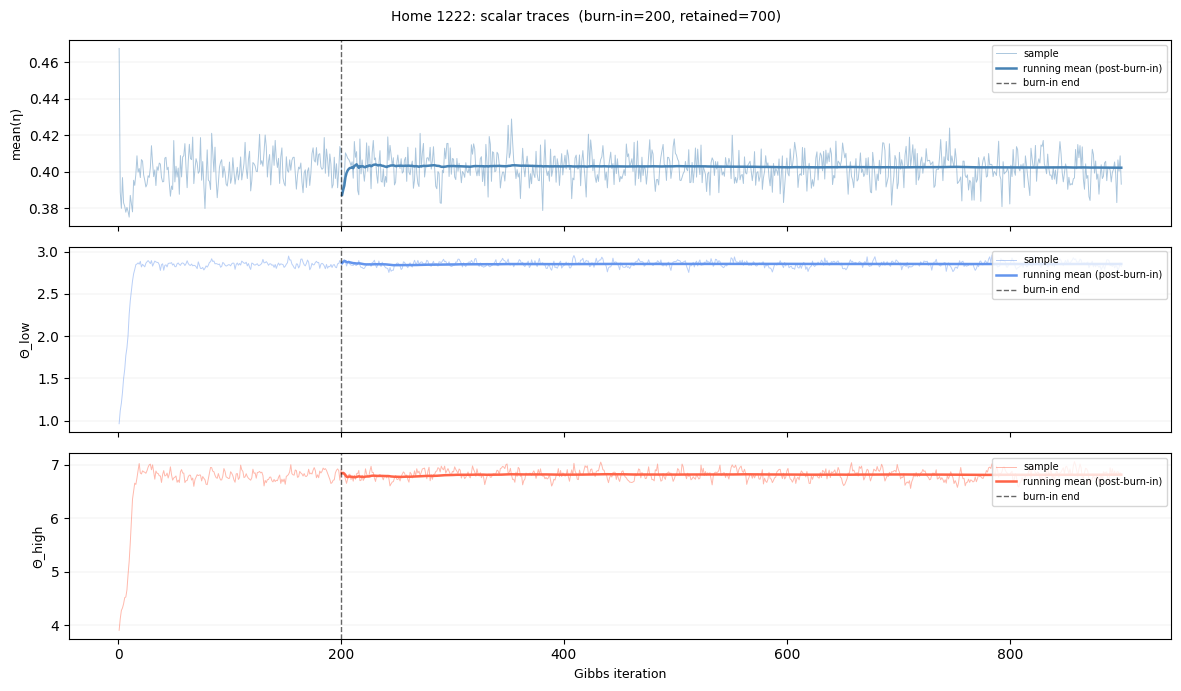

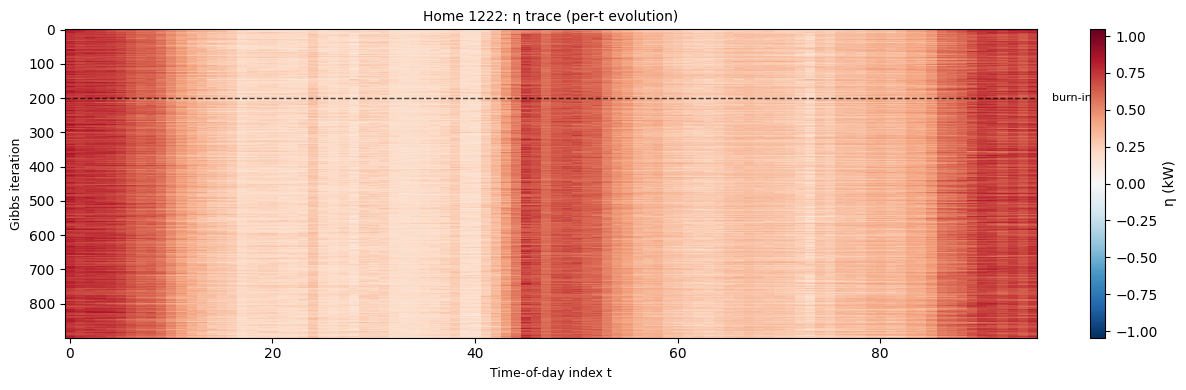

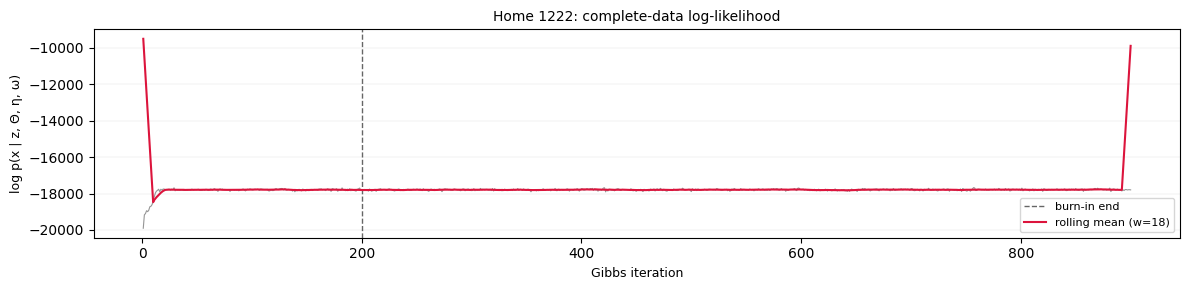

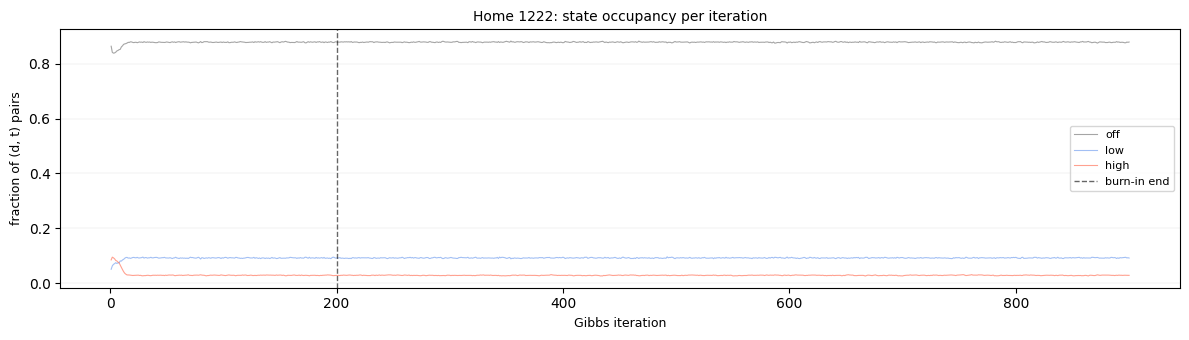

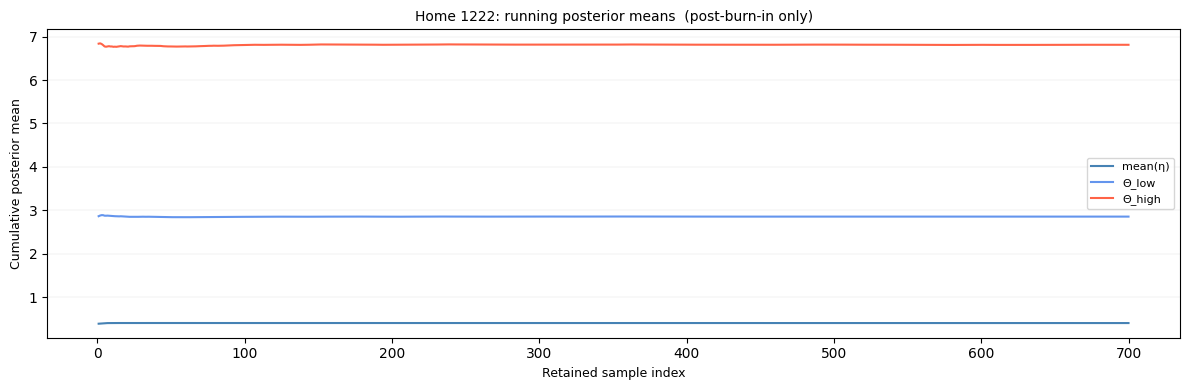

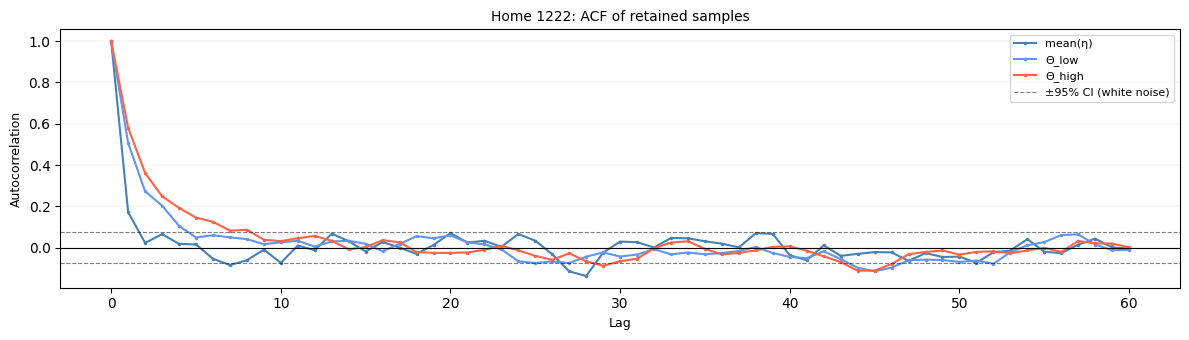

In [21]:
ev_hids = [hid for hid in inferences
           if bool(test_df_sub[test_df_sub['home_id']==hid]['has_ev'].iloc[0])]
diag_hid = ev_hids[0] if ev_hids else next(iter(inferences))
print(f'Showing convergence for home {diag_hid}')

# Re-run with record_traces=True if not already stored
# (infer_all sets record_traces=True by default — we check)
inf_diag = inferences[diag_hid]
if inf_diag.eta_trace is not None:
    figs = cvg.plot_all_diagnostics(inf_diag)
    for fig in figs:
        plt.show()
else:
    print('Traces not recorded (record_traces=False in infer_home call).')


## 8. Posterior z heatmaps — one EV home, one non-EV home

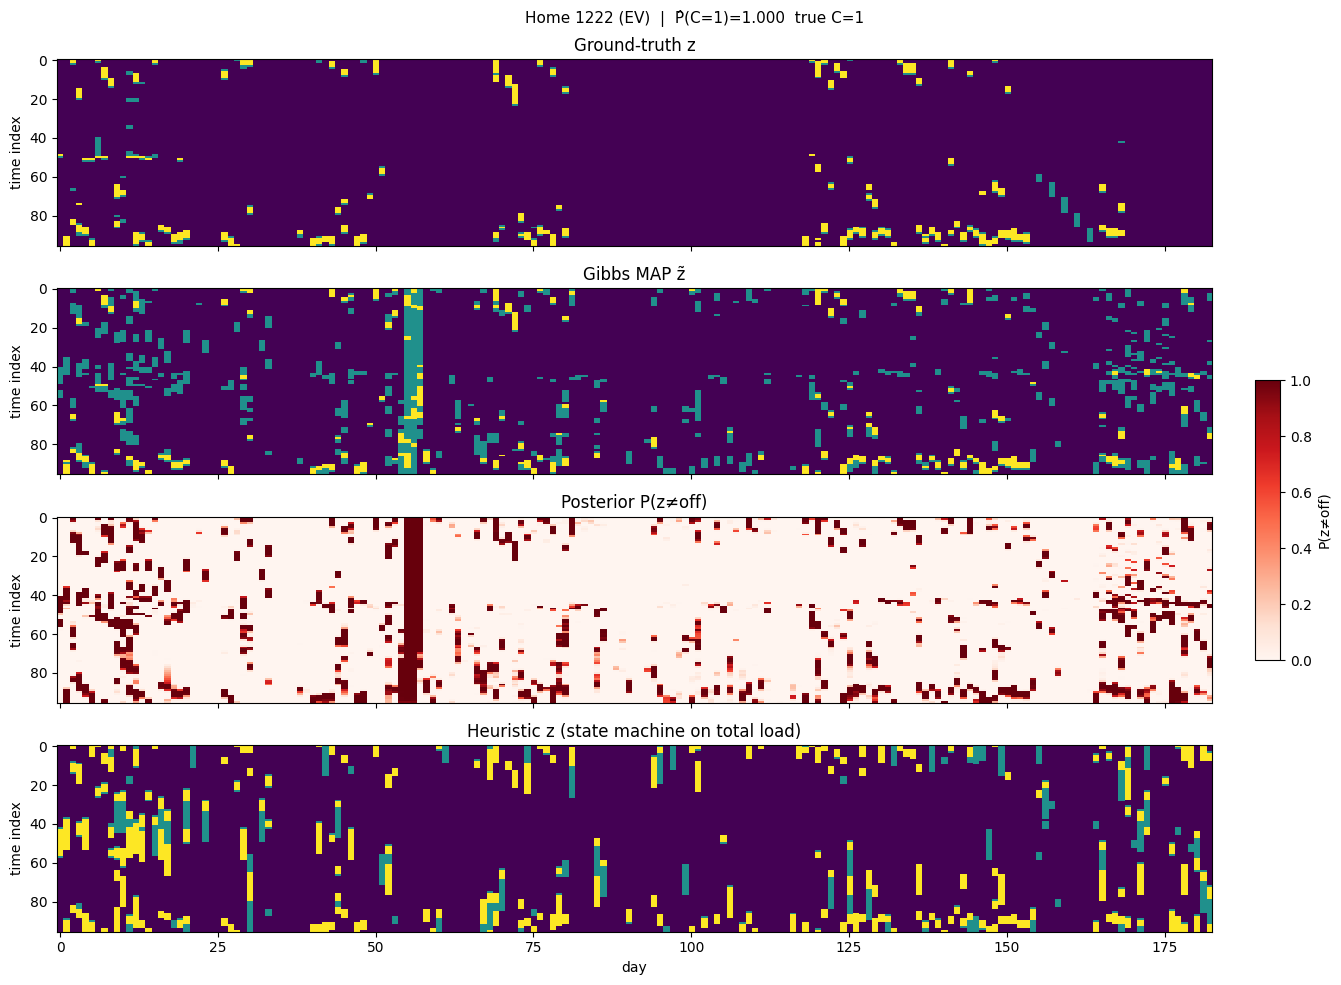

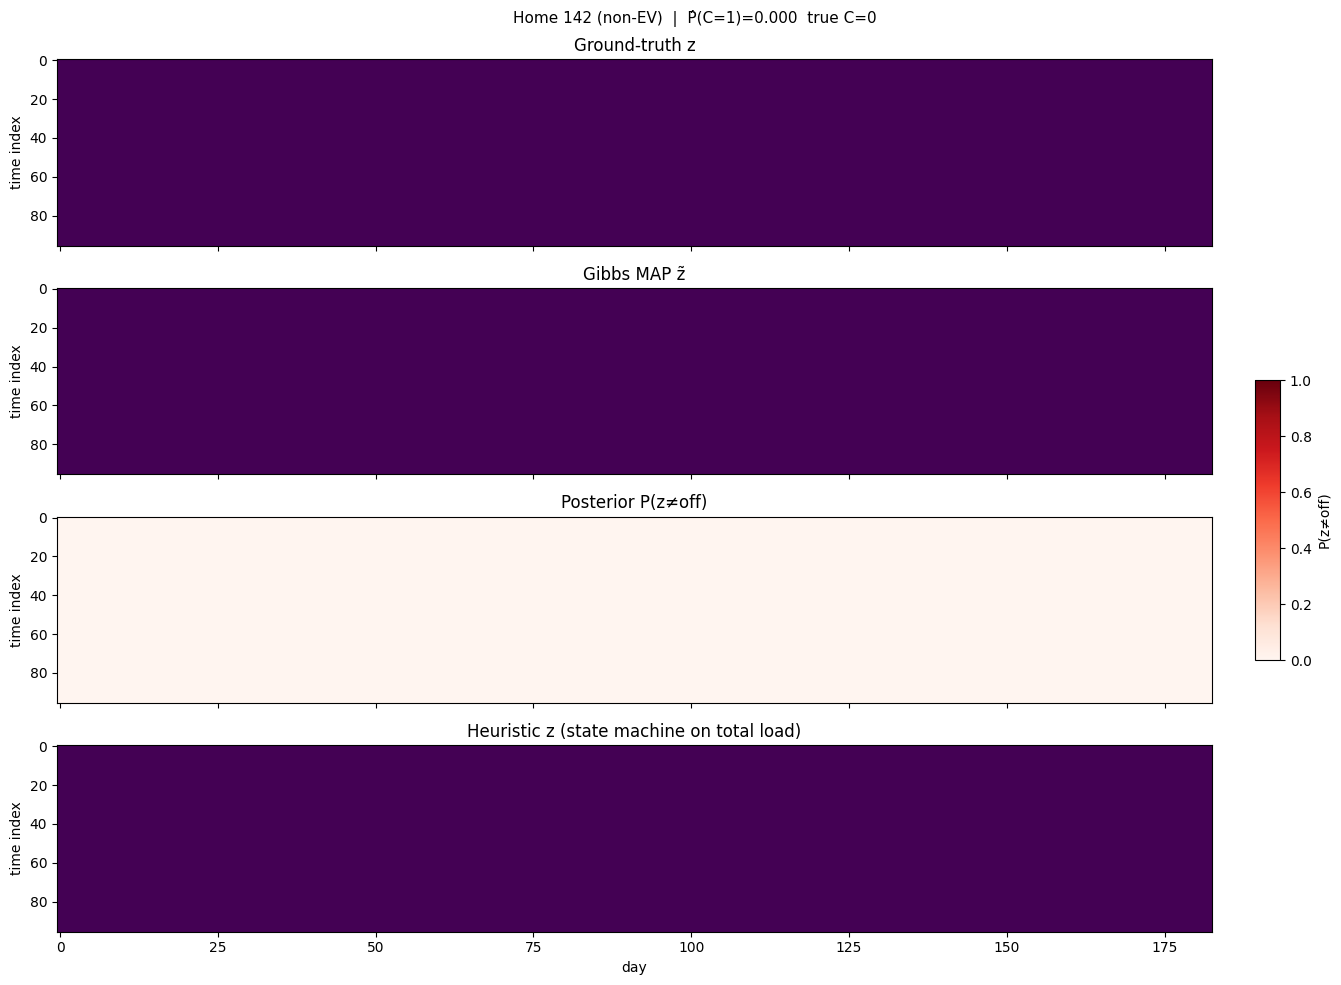

In [22]:
non_ev_hids = [hid for hid in inferences
               if not bool(test_df_sub[test_df_sub['home_id']==hid]['has_ev'].iloc[0])]

for hid, label in [(ev_hids[0], 'EV'), (non_ev_hids[0], 'non-EV')]:
    g    = test_df_sub[test_df_sub['home_id']==hid].sort_values(['day','time_index'])
    D    = g['day'].nunique()
    z_tr = g['charge_state'].to_numpy().reshape(D, 96)
    inf  = inferences[hid]
    heur = heuristic_states_test.get(hid, np.zeros(D*96, dtype=int))[:D*96].reshape(D, 96)

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Home {hid} ({label})  |  P̂(C=1)={inf.c_samples.mean():.3f}  '
                 f'true C={int(g["has_ev"].iloc[0])}', fontsize=11)

    axes[0].imshow(z_tr.T, aspect='auto', cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[0].set_title('Ground-truth z'); axes[0].set_ylabel('time index')

    axes[1].imshow(inf.z_hat.T, aspect='auto', cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[1].set_title('Gibbs MAP z̃'); axes[1].set_ylabel('time index')

    p_chg = 1.0 - inf.z_marginals[:,:,0]
    im = axes[2].imshow(p_chg.T, aspect='auto', cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    axes[2].set_title('Posterior P(z≠off)'); axes[2].set_ylabel('time index')

    axes[3].imshow(heur.T, aspect='auto', cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[3].set_title('Heuristic z (state machine on total load)')
    axes[3].set_xlabel('day'); axes[3].set_ylabel('time index')

    # Reserve a strip on the right for the colorbar without disturbing any subplot width
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    cbar_ax = fig.add_axes([0.90, 0.33, 0.018, 0.28])
    fig.colorbar(im, cax=cbar_ax, label='P(z≠off)')

    plt.show()


## 9. Diagnostic: inferred posterior vs ground-truth $x^{\mathrm{Non\text{-}EV}}$

For one home, compare the inferred $\eta^{(n)}$ and $\omega^{(n)}$ posteriors
to the empirical mean/std of the true non-EV signal (which the model never
sees at inference time). Three panels: mean profile, std profile, and the
per-timestep z-error rates (FP = predicting charging when truly off; FN =
the reverse). When inference over-predicts EV charging, this plot localizes
**where** in the day the misattribution happens — typically at times where
inferred $\eta$ falls below the true non-EV mean (the residual $x - \eta_{\text{inferred}}$
is positive, the sampler attributes it to a charging state instead of $\omega$).

Diagnosing home 1417


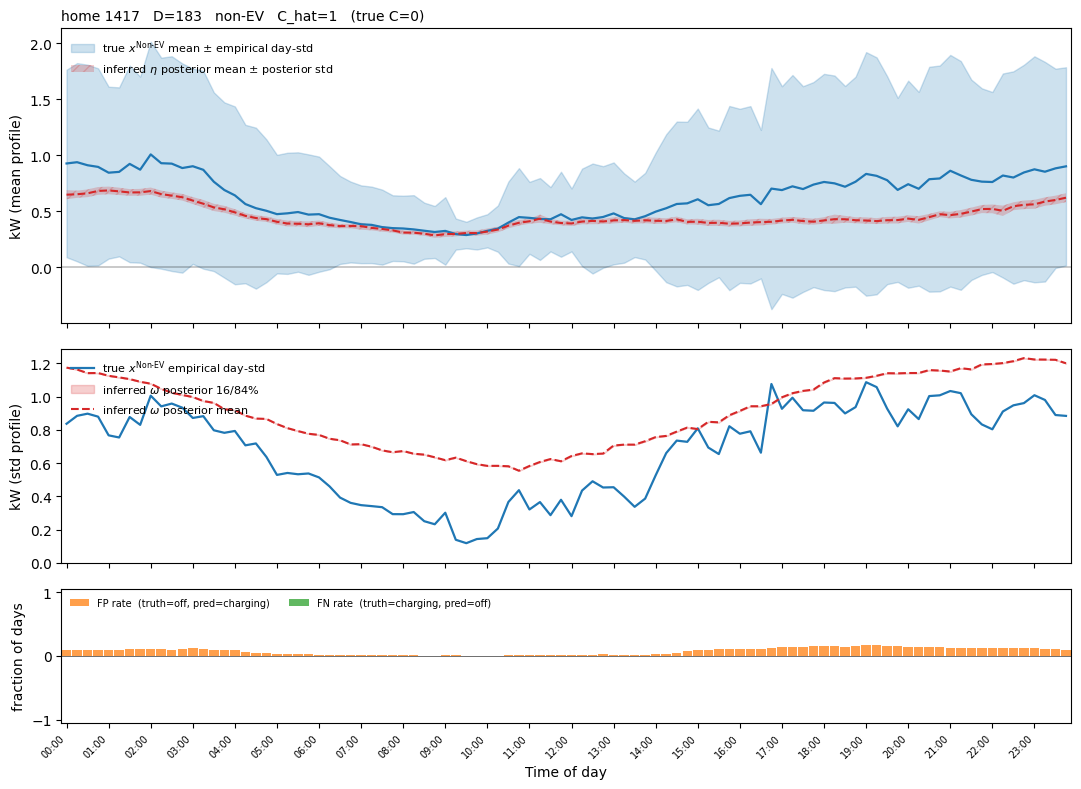

In [23]:
# Pick a home to diagnose. Default: first EV home with at least some
# false positives (i.e. where the over-prediction is visible).
# diag_home_id = ev_hids[] if 'ev_hids' in dir() and len(ev_hids) else \
#                next(iter(inferences))

diag_home_id = 1417
print(f'Diagnosing home {diag_home_id}')

fig_diag = bgp.plot_inference_vs_truth(
    test_df  = test_df_sub,
    inference = inferences[diag_home_id],
    params    = params,
    home_id   = diag_home_id,
)
plt.show()

In [15]:
HOME_IDS

[1222, 1417]